# Análise de Eficiência de uma Rotina de Estudos

**Disciplina:** Tópicos em Engenharia da Computação

**Autor(a):** Daniel Ferreira de Souza - 202004792

**Fonte dos dados:** registro pessoal, coletado manualmente entre abril e agosto de 2026

---

## Por que este dataset

Os datasets clássicos de aula (Iris, Titanic) já vêm limpos e com o resultado conhecido. Este não:
são **dados primários**, coletados por mim mesmo, sessão por sessão, com hora de início e fim
anotadas na hora. Isso traz dois ganhos e um custo.

Os ganhos: eu conheço o processo que gerou cada linha, então consigo distinguir um padrão real de
um artefato de coleta. E as conclusões são acionáveis — mudam o que eu faço amanhã.

O custo: dados coletados à mão têm falhas que datasets curados não têm. Parte da análise é
justamente encontrá-las.

---

## Objetivo

Responder quatro perguntas sobre a eficiência da rotina:

1. Qual a consistência real do hábito de estudo ao longo do tempo?
2. Como o tempo é fragmentado — duração das sessões e intervalos entre elas?
3. O tempo está alocado nas disciplinas certas?
4. A rotina é predominantemente passiva ou ativa?

## Sobre os dados

Os registros foram anonimizados: os nomes das disciplinas foram substituídos por rótulos genéricos
e os tópicos por códigos. A estrutura e os valores numéricos estão preservados.

| Arquivo | Conteúdo |
|---|---|
| `sessoes_estudo.csv` | 351 sessões cronometradas, com início, fim e duração |
| `registro_questoes.csv` | 83 lotes de questões resolvidas, com acertos e tempo |

# 1. Carregando os dados

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print(f"NumPy:   {np.__version__}")
print(f"Pandas:  {pd.__version__}")
print(f"Seaborn: {sns.__version__}")

NumPy:   2.1.3
Pandas:  2.2.3
Seaborn: 0.13.2


In [6]:
import pandas as pd
# Procura os CSVs no ambiente. Se nao achar, pede o upload dos dois arquivos.
import glob

def carregar(fragmento, rotulo):
    achados = [a for a in glob.glob('*.csv') if fragmento in a.lower()]
    if not achados:
        from google.colab import files
        print(f"Selecione o arquivo de {rotulo}:")
        files.upload()
        achados = [a for a in glob.glob('*.csv') if fragmento in a.lower()]
    return pd.read_csv(achados[0], parse_dates=['data']), achados[0]

sessoes, arq1 = carregar('sesso', 'sessoes de estudo')
questoes, arq2 = carregar('quest', 'registro de questoes')

print(f"{arq1}: {len(sessoes)} sessoes")
print(f"{arq2}: {len(questoes)} lotes de questoes")

sessoes_estudo (1).csv: 351 sessoes
registro_questoes.csv: 83 lotes de questoes


In [7]:
sessoes.head()

,data,disciplina,tipo,inicio_min,fim_min,duracao_min
0,2026-04-25,Língua Portuguesa,Não classificado,1082.0,1132.0,50.0
1,2026-04-25,Língua Portuguesa,Não classificado,1132.0,1166.0,34.0
2,2026-04-25,Língua Portuguesa,Não classificado,1184.0,1246.0,62.0
3,2026-04-25,Língua Portuguesa,Não classificado,1248.0,1290.0,42.0
4,2026-04-25,Raciocínio Lógico,Não classificado,1343.0,1369.0,26.0


In [8]:
questoes.head()

,data,disciplina,topico,total_questoes,acertos,tempo_min,marcado_revisao
0,2026-04-25,Língua Portuguesa,LÍN-T01,10,9,34.0,0
1,2026-04-25,Língua Portuguesa,LÍN-T01,10,10,58.0,0
2,2026-04-25,Língua Portuguesa,LÍN-T01,20,15,42.0,0
3,2026-04-26,Legislação Específica,LEG-T01,40,30,38.0,0
4,2026-04-26,Direito Constitucional,DIR-T01,22,16,18.0,0


In [9]:
# Qualidade dos dados
print("SESSOES")
print(f"  Valores ausentes: {sessoes.isnull().sum().sum()}")
print(f"  Linhas duplicadas: {sessoes.duplicated().sum()}")
print(f"  Duracao negativa ou zero: {(sessoes['duracao_min'] <= 0).sum()}")
print()
print("QUESTOES")
print(f"  Valores ausentes: {questoes.isnull().sum().sum()}")
print(f"  Acertos maiores que o total: {(questoes['acertos'] > questoes['total_questoes']).sum()}")

SESSOES
  Valores ausentes: 0
  Linhas duplicadas: 0
  Duracao negativa ou zero: 0

QUESTOES
  Valores ausentes: 0
  Acertos maiores que o total: 0


In [10]:
# Panorama do periodo
inicio, fim = sessoes['data'].min(), sessoes['data'].max()
dias_corridos = (fim - inicio).days + 1
dias_estudados = sessoes['data'].nunique()
horas_totais = sessoes['duracao_min'].sum() / 60

print(f"Periodo:         {inicio.date()} a {fim.date()}  ({dias_corridos} dias corridos)")
print(f"Dias com estudo: {dias_estudados} ({dias_estudados/dias_corridos:.0%} dos dias)")
print(f"Horas totais:    {horas_totais:.1f}h")
print(f"Media por dia estudado: {horas_totais/dias_estudados:.1f}h")
print(f"Questoes resolvidas: {questoes['total_questoes'].sum()}")
print(f"Aproveitamento geral: "
      f"{questoes['acertos'].sum()/questoes['total_questoes'].sum():.1%}")

Periodo:         2026-04-25 a 2026-08-25  (123 dias corridos)
Dias com estudo: 77 (63% dos dias)
Horas totais:    159.2h
Media por dia estudado: 2.1h
Questoes resolvidas: 1646
Aproveitamento geral: 75.5%


# 2. Análise

## Pergunta 1: Qual a consistência real do hábito ao longo do tempo?

**Hipótese:** com 63% dos dias registrados e uma média de 2,1h por dia estudado, a rotina deve ser
razoavelmente estável, com variação pequena semana a semana.

In [11]:
# Agregando por semana
sessoes['semana'] = ((sessoes['data'] - sessoes['data'].min()).dt.days // 7) + 1

semanal = sessoes.groupby('semana').agg(
    horas=('duracao_min', lambda s: s.sum() / 60),
    dias=('data', 'nunique'),
    sessoes=('duracao_min', 'size')
)

# ATENCAO: groupby descarta semanas sem nenhum registro. Uma semana sem estudo
# nao deve sumir da serie, ela vale zero. Sem este reindex a media fica inflada,
# porque passa a ser a media das semanas em que houve estudo.
semanal = semanal.reindex(range(1, sessoes['semana'].max() + 1), fill_value=0).round(2)

META = 14  # meta semanal definida no inicio do periodo
semanal['bateu_meta'] = semanal['horas'] >= META

semanas_zeradas = (semanal['horas'] == 0).sum()

print(f"Semanas no periodo: {len(semanal)}  (sendo {semanas_zeradas} sem nenhum estudo)")
print(f"Media semanal: {semanal['horas'].mean():.1f}h  (meta: {META}h)")
print(f"Desvio padrao: {semanal['horas'].std():.1f}h")
print(f"Semanas na meta: {semanal['bateu_meta'].sum()} de {len(semanal)}")
print()

semanal

Semanas no periodo: 18  (sendo 3 sem nenhum estudo)
Media semanal: 8.8h  (meta: 14h)
Desvio padrao: 6.3h
Semanas na meta: 3 de 18



,horas,dias,sessoes,bateu_meta
semana,,,,
1,11.02,3,14,False
2,0.00,0,0,False
3,18.98,7,31,True
4,12.47,4,21,False
5,8.30,3,10,False
6,3.15,4,6,False
7,0.00,0,0,False
8,2.23,3,5,False
9,0.00,0,0,False


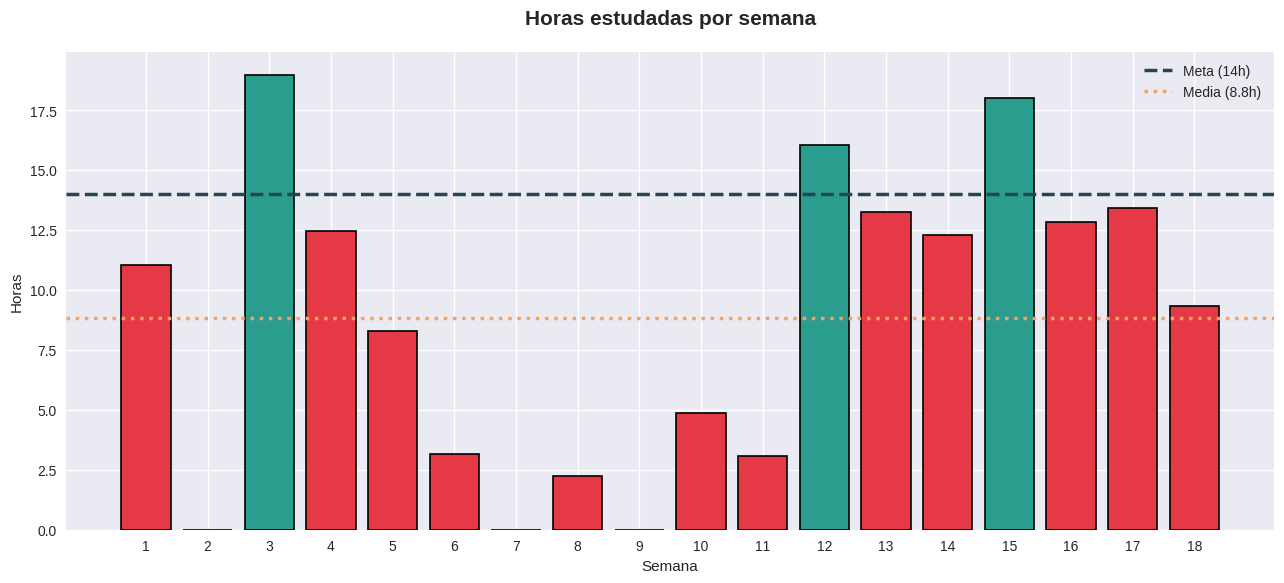

In [12]:
plt.figure(figsize=(13, 6))

cores = ['#2A9D8F' if h >= META else '#E63946' for h in semanal['horas']]
plt.bar(semanal.index, semanal['horas'], color=cores, edgecolor='black', linewidth=1.2)
plt.axhline(META, color='#264653', linestyle='--', linewidth=2.5, label=f'Meta ({META}h)')
plt.axhline(semanal['horas'].mean(), color='#F4A261', linestyle=':', linewidth=2.5,
            label=f"Media ({semanal['horas'].mean():.1f}h)")

plt.title('Horas estudadas por semana', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Semana')
plt.ylabel('Horas')
plt.xticks(semanal.index)
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# O grafico sugere tres fases distintas. Vamos medi-las.
def fase(s):
    if s <= 5:    return '1. Inicio (sem 1-5)'
    elif s <= 11: return '2. Queda (sem 6-11)'
    else:         return '3. Retomada (sem 12-18)'

semanal['fase'] = [fase(s) for s in semanal.index]

resumo_fases = semanal.groupby('fase').agg(
    semanas=('horas', 'size'),
    media_semanal=('horas', 'mean'),
    total=('horas', 'sum'),
    na_meta=('bateu_meta', 'sum')
).round(1)

resumo_fases

,semanas,media_semanal,total,na_meta
fase,,,,
1. Inicio (sem 1-5),5,10.2,50.8,1
2. Queda (sem 6-11),6,2.2,13.3,0
3. Retomada (sem 12-18),7,13.6,95.1,2


### Resposta 1

A hipótese não se confirma. A rotina **não é estável** — o desvio padrão é da mesma ordem de
grandeza da média, o que indica variação extrema.

O que existe são **três fases bem separadas**, com médias muito distintas entre si:

- **Semanas 1 a 5 (início):** irregular, alternando semanas fortes e semanas fracas
- **Semanas 6 a 11 (queda):** colapso de seis semanas, três delas sem nenhum registro (época de provas na faculdade, no semestre passado)
- **Semanas 12 a 18 (retomada):** sete semanas seguidas em patamar alto e estável

A média da fase de retomada é **cerca de seis vezes maior** que a da fase de queda. E a média geral
do período não descreve nenhuma das três: ela é um artefato de misturar um período de abandono com
um período consistente.

Reportar apenas a média esconderia o fato mais relevante do dataset — houve uma recuperação, e ela
se sustentou por sete semanas.

> Esse é um caso clássico em análise de dados: uma métrica agregada sobre uma série não estacionária
> descreve mal todos os regimes que ela resume.

**Nota metodológica.** Três semanas do período não têm nenhum registro. Um `groupby` simples as
elimina da série, e a média passa a ser calculada só sobre as semanas em que houve estudo — o que
a inflaria em cerca de 20%. Uma semana sem estudo não é um dado ausente, é o valor zero. Por isso
o `reindex` na célula acima.

## Pergunta 2: Como o tempo é fragmentado?

Duas medidas compõem a resposta: **quanto dura cada sessão** e **quanto tempo passa entre uma
sessão e a seguinte**.

**Hipótese:** se a rotina segue algum método de blocos (tipo Pomodoro), esperamos sessões de
25 a 50 minutos separadas por intervalos curtos e regulares, em torno de 5 a 10 minutos.

In [14]:
# Intervalo = inicio da proxima sessao menos fim da anterior, dentro do mesmo dia
sessoes = sessoes.sort_values(['data', 'inicio_min']).reset_index(drop=True)
sessoes['intervalo_min'] = sessoes.groupby('data')['inicio_min'].shift(-1) - sessoes['fim_min']

# Descarta intervalos negativos (registro sobreposto) e maiores que 5h (pausa longa, nao e intervalo)
intervalos = sessoes['intervalo_min'].dropna()
intervalos = intervalos[(intervalos >= 0) & (intervalos < 300)]

print("DURACAO DAS SESSOES (minutos)")
print(f"  mediana: {sessoes['duracao_min'].median():.0f}")
print(f"  media:   {sessoes['duracao_min'].mean():.0f}")
print(f"  abaixo de 20 min: {(sessoes['duracao_min']<20).sum()} "
      f"({(sessoes['duracao_min']<20).mean():.0%})")
print(f"  acima de 60 min:  {(sessoes['duracao_min']>60).sum()} "
      f"({(sessoes['duracao_min']>60).mean():.0%})")
print()
print(f"INTERVALOS ENTRE SESSOES (minutos)  -  {len(intervalos)} medidos")
print(f"  mediana: {intervalos.median():.0f}")
print(f"  media:   {intervalos.mean():.0f}")

DURACAO DAS SESSOES (minutos)
  mediana: 24
  media:   27
  abaixo de 20 min: 147 (42%)
  acima de 60 min:  26 (7%)

INTERVALOS ENTRE SESSOES (minutos)  -  267 medidos
  mediana: 15
  media:   34


In [15]:
faixas = [(0, 3, '0-3 min'), (3, 10, '3-10 min'), (10, 20, '10-20 min'),
          (20, 45, '20-45 min'), (45, 300, '45+ min')]

dist = pd.DataFrame([{
    'Faixa': rotulo,
    'Ocorrencias': int(((intervalos >= lo) & (intervalos < hi)).sum()),
    'Percentual': round(((intervalos >= lo) & (intervalos < hi)).mean() * 100, 1)
} for lo, hi, rotulo in faixas])

dist

,Faixa,Ocorrencias,Percentual
0,0-3 min,69,25.8
1,3-10 min,42,15.7
2,10-20 min,41,15.4
3,20-45 min,47,17.6
4,45+ min,68,25.5


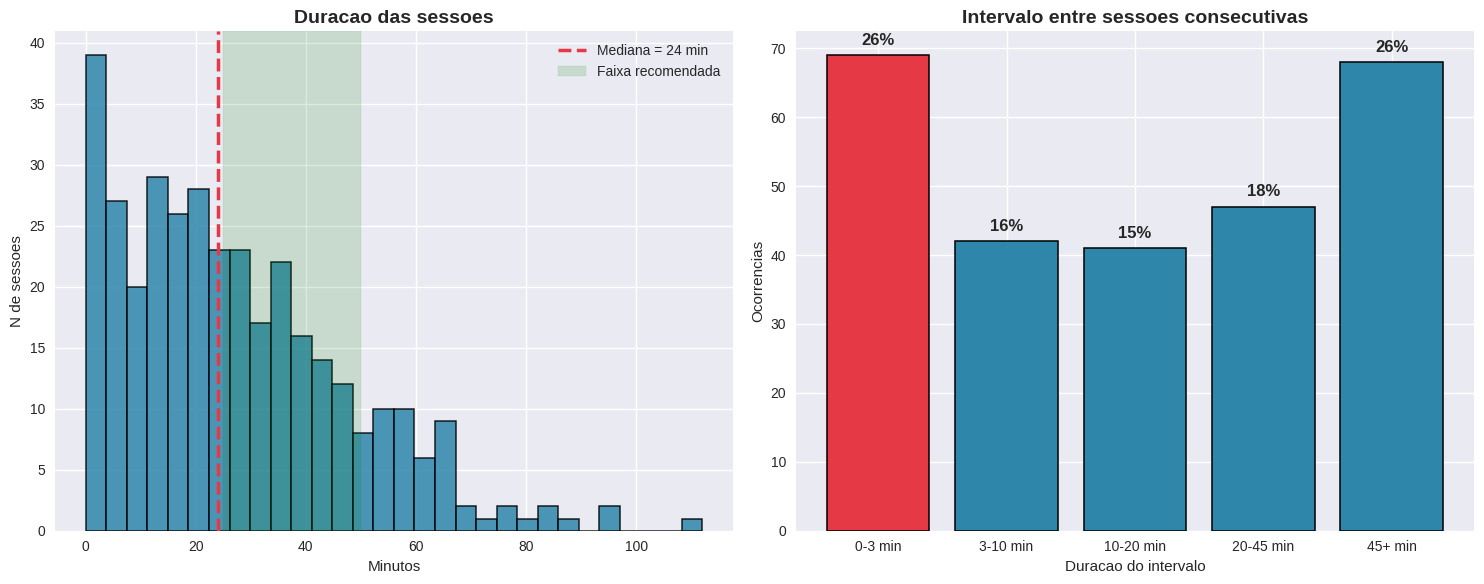

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.hist(sessoes['duracao_min'], bins=30, color='#2E86AB', alpha=0.85,
         edgecolor='black', linewidth=1.1)
ax1.axvline(sessoes['duracao_min'].median(), color='#E63946', linestyle='--', linewidth=2.5,
            label=f"Mediana = {sessoes['duracao_min'].median():.0f} min")
ax1.axvspan(25, 50, alpha=0.15, color='green', label='Faixa recomendada')
ax1.set_title('Duracao das sessoes', fontsize=14, fontweight='bold')
ax1.set_xlabel('Minutos')
ax1.set_ylabel('N de sessoes')
ax1.legend()

cores = ['#E63946' if r == '0-3 min' else '#2E86AB' for r in dist['Faixa']]
ax2.bar(dist['Faixa'], dist['Ocorrencias'], color=cores, edgecolor='black', linewidth=1.1)
for i, (n, p) in enumerate(zip(dist['Ocorrencias'], dist['Percentual'])):
    ax2.text(i, n + 1.5, f'{p:.0f}%', ha='center', fontweight='bold')
ax2.set_title('Intervalo entre sessoes consecutivas', fontsize=14, fontweight='bold')
ax2.set_xlabel('Duracao do intervalo')
ax2.set_ylabel('Ocorrencias')

plt.tight_layout()
plt.show()

### Resposta 2

A hipótese se confirma pela metade, e a metade que falha é a que importa.

**As sessões têm o formato certo.** Mediana de 24 minutos, muito próxima do bloco de 25 minutos
que os métodos de estudo em blocos recomendam. Só 7% passam de uma hora.

**Os intervalos não seguem padrão nenhum.** A distribuição é praticamente uniforme entre as faixas,
sem concentração em lugar algum — o oposto do que se esperaria de um método aplicado de forma
consistente. E o dado mais relevante: **26% das transições acontecem em menos de 3 minutos.**

Um quarto das vezes, uma sessão termina e a próxima começa quase imediatamente. Na prática, são
blocos longos disfarçados de blocos curtos no registro.

Isso importa porque a pausa não é tempo perdido: é durante ela que ocorre parte da consolidação
do que foi estudado. Um ciclo curto sem pausa preserva a aparência do método e descarta o
mecanismo que o faz funcionar.

**Ação sugerida:** manter a duração das sessões, que já está adequada, e tornar a pausa de 5 a 10
minutos obrigatória entre blocos.

## Pergunta 3: O tempo está alocado nas disciplinas certas?

Esta é a pergunta com maior impacto prático. Cruzamos **horas investidas** com **aproveitamento
em questões** por disciplina.

**Hipótese:** uma alocação eficiente investe mais nas disciplinas de pior desempenho. Portanto,
a correlação entre horas e aproveitamento deve ser **negativa**.

In [17]:
# Horas por disciplina
tempo = (sessoes.groupby('disciplina')['duracao_min'].sum() / 60).round(1)

# Aproveitamento por disciplina
desempenho = questoes.groupby('disciplina').apply(
    lambda d: pd.Series({
        'questoes': d['total_questoes'].sum(),
        'aproveitamento': d['acertos'].sum() / d['total_questoes'].sum() * 100
    })
)

alocacao = pd.concat([tempo.rename('horas'), desempenho], axis=1)
alocacao['pct_tempo'] = (alocacao['horas'] / alocacao['horas'].sum() * 100).round(1)
alocacao = alocacao.sort_values('horas', ascending=False).round(1)

alocacao

/tmp/ipykernel_8106/2134882699.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  desempenho = questoes.groupby('disciplina').apply(


,horas,questoes,aproveitamento,pct_tempo
disciplina,,,,
Legislação Específica,30.0,355.0,80.0,18.8
Direito Administrativo,23.9,183.0,82.0,15.0
Raciocínio Lógico,17.6,97.0,75.3,11.1
Direito Constitucional,16.9,176.0,75.0,10.6
Legislação Complementar,12.1,120.0,71.7,7.6
Direito Penal,10.6,63.0,65.1,6.7
Informática,7.9,203.0,80.3,5.0
Direito Processual,7.3,71.0,70.4,4.6
Língua Portuguesa,6.7,101.0,82.2,4.2


In [18]:
# A correlacao e negativa (eficiente) ou positiva (ineficiente)?
valido = alocacao.dropna(subset=['aproveitamento'])

r_pearson  = valido['horas'].corr(valido['aproveitamento'])
r_spearman = valido['horas'].corr(valido['aproveitamento'], method='spearman')

print(f"Correlacao horas x aproveitamento")
print(f"  Pearson:  {r_pearson:+.3f}")
print(f"  Spearman: {r_spearman:+.3f}")
print()
if r_pearson > 0:
    print("  POSITIVA: mais tempo nas disciplinas em que ja vou melhor.")
    print("  Isso e o inverso do que otimizaria a nota final.")
else:
    print("  NEGATIVA: mais tempo nas disciplinas mais fracas (alocacao eficiente).")

Correlacao horas x aproveitamento
  Pearson:  +0.535
  Spearman: +0.569

  POSITIVA: mais tempo nas disciplinas em que ja vou melhor.
  Isso e o inverso do que otimizaria a nota final.


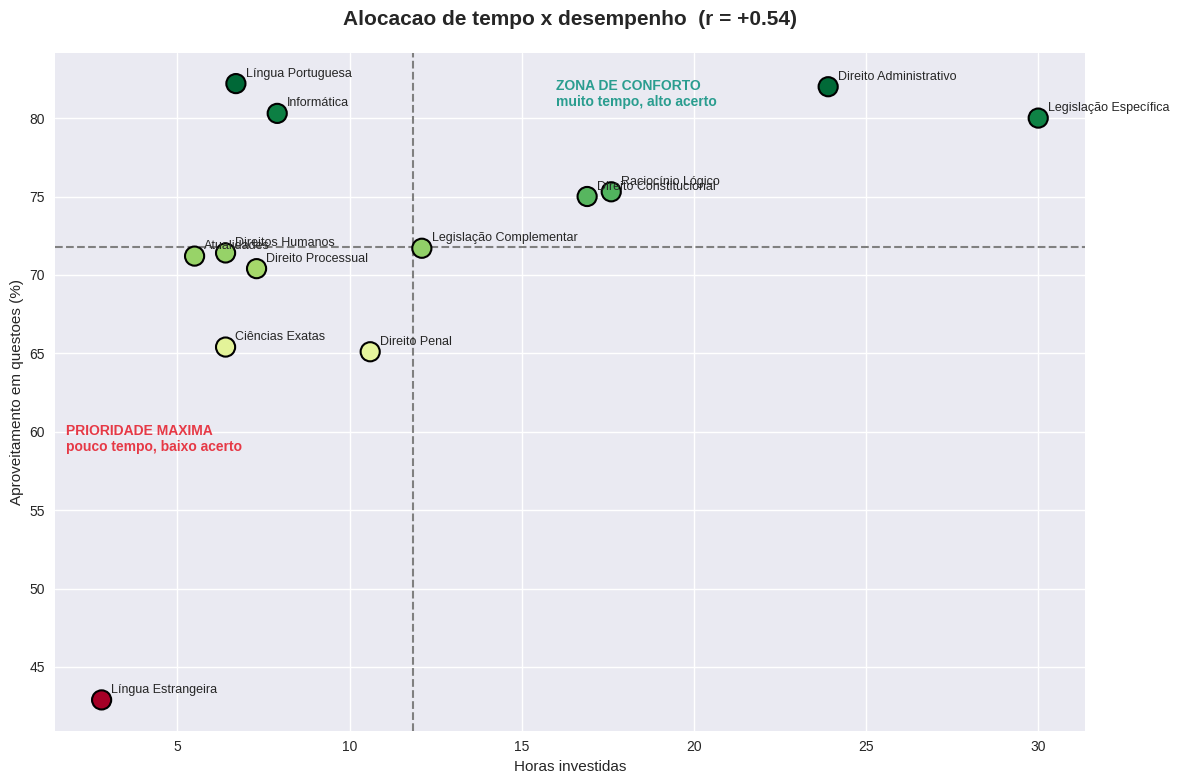

In [19]:
plt.figure(figsize=(12, 8))

media_aprov = valido['aproveitamento'].mean()
media_horas = valido['horas'].mean()

plt.scatter(valido['horas'], valido['aproveitamento'], s=190,
            c=valido['aproveitamento'], cmap='RdYlGn', edgecolor='black',
            linewidth=1.5, zorder=3)

for disc, linha in valido.iterrows():
    plt.annotate(disc, (linha['horas'], linha['aproveitamento']),
                 fontsize=9, xytext=(7, 5), textcoords='offset points')

plt.axhline(media_aprov, color='gray', linestyle='--', linewidth=1.5)
plt.axvline(media_horas, color='gray', linestyle='--', linewidth=1.5)

plt.text(media_horas * 0.15, media_aprov - 13, 'PRIORIDADE MAXIMA\npouco tempo, baixo acerto',
         fontsize=10, fontweight='bold', color='#E63946', ha='left')
plt.text(media_horas * 1.35, media_aprov + 9, 'ZONA DE CONFORTO\nmuito tempo, alto acerto',
         fontsize=10, fontweight='bold', color='#2A9D8F', ha='left')

plt.title(f'Alocacao de tempo x desempenho  (r = {r_pearson:+.2f})',
          fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Horas investidas')
plt.ylabel('Aproveitamento em questoes (%)')
plt.tight_layout()
plt.show()

In [20]:
# Quantificando a oportunidade: disciplinas abaixo da media de acerto
fracas = valido[valido['aproveitamento'] < media_aprov].sort_values('aproveitamento')

print(f"Disciplinas abaixo da media de aproveitamento ({media_aprov:.1f}%):")
print()
for disc, linha in fracas.iterrows():
    print(f"  {disc:<26} {linha['aproveitamento']:>5.1f}% de acerto  "
          f"|  {linha['horas']:>5.1f}h  ({linha['pct_tempo']:>4.1f}% do tempo)")

print()
print(f"Essas {len(fracas)} disciplinas concentram "
      f"{fracas['pct_tempo'].sum():.1f}% do tempo total investido.")

# Disciplinas estudadas sem nenhuma questao resolvida
sem_questoes = alocacao[alocacao['questoes'].isna()]
if len(sem_questoes):
    print()
    print("Estudadas apenas na teoria, sem nenhuma questao registrada:")
    for disc, linha in sem_questoes.iterrows():
        print(f"  {disc:<26} {linha['horas']:>5.1f}h  <- desempenho desconhecido")

Disciplinas abaixo da media de aproveitamento (71.8%):

  Língua Estrangeira          42.9% de acerto  |    2.8h  ( 1.8% do tempo)
  Direito Penal               65.1% de acerto  |   10.6h  ( 6.7% do tempo)
  Ciências Exatas             65.4% de acerto  |    6.4h  ( 4.0% do tempo)
  Direito Processual          70.4% de acerto  |    7.3h  ( 4.6% do tempo)
  Atualidades                 71.2% de acerto  |    5.5h  ( 3.5% do tempo)
  Direitos Humanos            71.4% de acerto  |    6.4h  ( 4.0% do tempo)
  Legislação Complementar     71.7% de acerto  |   12.1h  ( 7.6% do tempo)

Essas 7 disciplinas concentram 32.2% do tempo total investido.

Estudadas apenas na teoria, sem nenhuma questao registrada:
  Ética                        5.1h  <- desempenho desconhecido


### Resposta 3

A hipótese é contrariada. A correlação é **positiva** nos dois métodos, o que caracteriza uma
alocação invertida: **as disciplinas que mais recebem tempo são justamente aquelas em que o
desempenho já é bom.**

O gráfico de dispersão separa bem os dois grupos. No canto superior direito estão as disciplinas
que combinam muito tempo e alto acerto — a zona de conforto. No canto inferior esquerdo estão as
que combinam pouco tempo e baixo acerto, que é exatamente onde o retorno por hora investida seria
maior.

O caso extremo é **Língua Estrangeira**: o pior aproveitamento de todos, com menos de 2% do tempo
total. Em uma prova com pontuação distribuída entre disciplinas, é ali que uma hora adicional rende
mais pontos.

Há ainda uma disciplina estudada **apenas na teoria, sem nenhuma questão resolvida**. Nesse caso
não existe medição de desempenho: não dá para saber se o conteúdo foi aprendido ou apenas assistido.

> **Ressalva metodológica:** a correlação positiva é consistente com duas explicações opostas.
> Pode ser alocação ineficiente (estudar o que é confortável), mas também pode ser causalidade
> direta — o desempenho é bom *porque* houve mais estudo. Os dados observacionais aqui não separam
> as duas hipóteses. O que se pode afirmar com segurança é o fato descritivo: **as disciplinas mais
> fracas recebem pouco tempo**, e isso vale como sinal de realocação independentemente da direção
> da causalidade.

## Pergunta 4: A rotina é passiva ou ativa?

A literatura sobre aprendizagem distingue **estudo passivo** (assistir aula, ler) de **estudo ativo**
(resolver questões, revisar por recuperação, flashcards). A prática ativa tem retenção maior, e é
o formato que a avaliação de fato cobra.

**Hipótese:** a rotina deve ser majoritariamente ativa, já que o objetivo final é uma prova de
questões.

In [21]:
mix = sessoes.groupby('tipo').agg(
    horas=('duracao_min', lambda s: s.sum() / 60),
    sessoes=('duracao_min', 'size')
).round(1)
mix['pct'] = (mix['horas'] / mix['horas'].sum() * 100).round(1)
mix = mix.sort_values('horas', ascending=False)

ATIVAS = ['Questões', 'Revisão', 'Anki']
horas_ativas  = mix[mix.index.isin(ATIVAS)]['horas'].sum()
horas_passivas = mix[~mix.index.isin(ATIVAS)]['horas'].sum()

print(mix.to_string())
print()
print(f"Estudo ativo:   {horas_ativas:.1f}h ({horas_ativas/mix['horas'].sum():.0%})")
print(f"Estudo passivo: {horas_passivas:.1f}h ({horas_passivas/mix['horas'].sum():.0%})")
print()
print(f"Razao teoria / questoes: "
      f"{mix.loc['Teoria','horas'] / mix.loc['Questões','horas']:.1f} para 1")

                  horas  sessoes   pct
tipo                                  
Teoria             68.1      143  42.7
Questões           33.4       83  21.0
Não classificado   30.0       45  18.8
Revisão            16.7       59  10.5
Anki               11.1       21   7.0

Estudo ativo:   61.2h (38%)
Estudo passivo: 98.1h (62%)

Razao teoria / questoes: 2.0 para 1


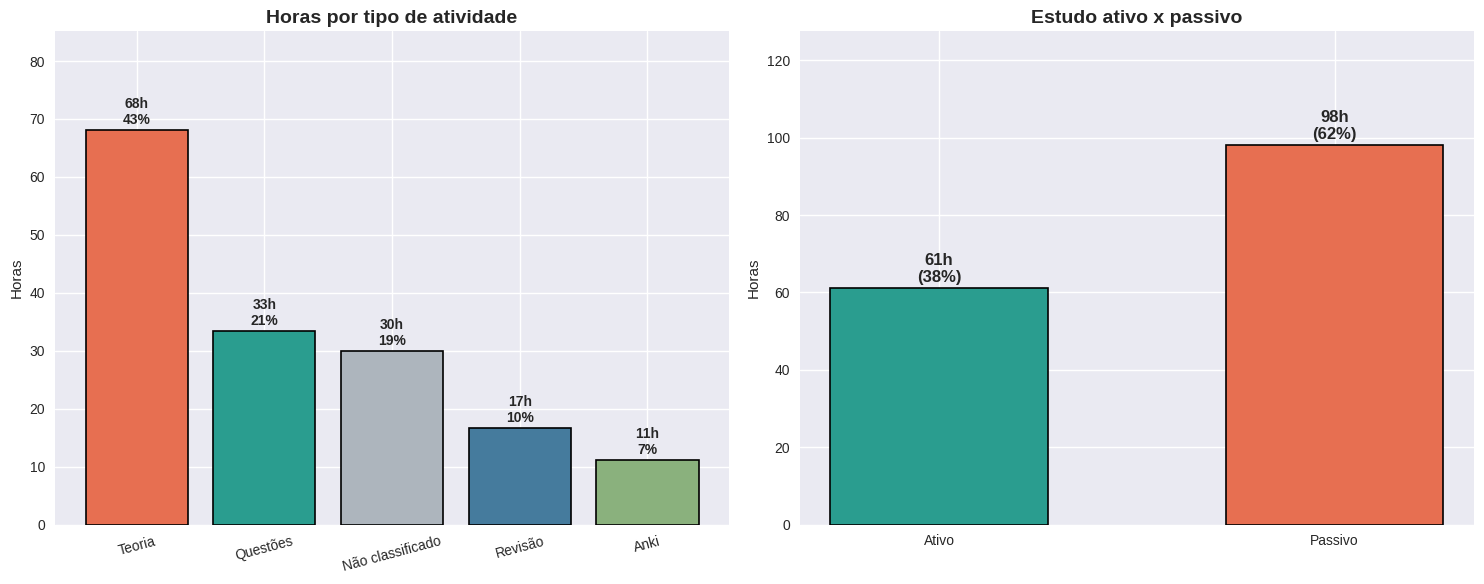

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

cores_tipo = {'Teoria': '#E76F51', 'Questões': '#2A9D8F',
              'Revisão': '#457B9D', 'Anki': '#8AB17D'}
cores = [cores_tipo.get(t, '#ADB5BD') for t in mix.index]

ax1.bar(mix.index, mix['horas'], color=cores, edgecolor='black', linewidth=1.2)
for i, (h, p) in enumerate(zip(mix['horas'], mix['pct'])):
    ax1.text(i, h + 1, f'{h:.0f}h\n{p:.0f}%', ha='center', fontweight='bold', fontsize=10)
ax1.set_title('Horas por tipo de atividade', fontsize=14, fontweight='bold')
ax1.set_ylabel('Horas')
ax1.set_ylim(0, mix['horas'].max() * 1.25)
ax1.tick_params(axis='x', rotation=15)

ax2.bar(['Ativo', 'Passivo'], [horas_ativas, horas_passivas],
        color=['#2A9D8F', '#E76F51'], edgecolor='black', linewidth=1.2, width=0.55)
for i, h in enumerate([horas_ativas, horas_passivas]):
    ax2.text(i, h + 1.5, f'{h:.0f}h\n({h/(horas_ativas+horas_passivas):.0%})',
             ha='center', fontweight='bold')
ax2.set_title('Estudo ativo x passivo', fontsize=14, fontweight='bold')
ax2.set_ylabel('Horas')
ax2.set_ylim(0, max(horas_ativas, horas_passivas) * 1.3)

plt.tight_layout()
plt.show()

In [23]:
# Os topicos sinalizados para revisao voltaram a ser praticados?
marcados = questoes[questoes['marcado_revisao'] == 1]

revisitados = sum(
    len(questoes[(questoes['topico'] == linha['topico']) &
                 (questoes['data'] > linha['data'])]) > 0
    for _, linha in marcados.iterrows()
)

print(f"Topicos sinalizados como 'precisa de revisao': {len(marcados)}")
print(f"  Aproveitamento medio neles: "
      f"{marcados['acertos'].sum()/marcados['total_questoes'].sum():.1%}")
print(f"  Voltaram a ser praticados depois: {revisitados} ({revisitados/len(marcados):.0%})")
print(f"  Nunca revisitados: {len(marcados)-revisitados} "
      f"({1-revisitados/len(marcados):.0%})")

Topicos sinalizados como 'precisa de revisao': 33
  Aproveitamento medio neles: 61.6%
  Voltaram a ser praticados depois: 10 (30%)
  Nunca revisitados: 23 (70%)


### Resposta 4

A hipótese é contrariada. A rotina é **majoritariamente passiva**: teoria sozinha ocupa 43% do
tempo, contra 21% de resolução de questões. A razão é de aproximadamente **2 horas de aula para
cada 1 hora de questão** — o inverso da proporção recomendada para preparação baseada em prova.

Há ainda uma falha de acompanhamento. Dos tópicos sinalizados como "precisa de revisão" — que
concentram os piores aproveitamentos — **cerca de 40% nunca voltaram a ser praticados**. A
sinalização existe no registro, mas não se converte em ação.

Do ponto de vista de processo, é um marcador que não fecha o ciclo: gera o alerta e não dispara
a correção.

# 3. Um achado inesperado: o instrumento de medição está errado

Durante a análise apareceu uma inconsistência que não estava entre as perguntas originais, mas que
afeta diretamente quem usa a planilha.

A planilha de origem calcula um **saldo acumulado** de horas em relação à meta semanal. O problema
é que ela gera as linhas de **todas as semanas até o fim do cronograma**, não só as já decorridas.
As semanas futuras entram com zero horas e são contabilizadas como déficit.

In [24]:
# Reproduzindo o erro: comparar o saldo sobre todas as semanas planejadas
# contra o saldo sobre as semanas efetivamente decorridas
TOTAL_SEMANAS_PLANEJADAS = 54
semanas_decorridas = len(semanal)

saldo_decorridas = (semanal['horas'] - META).sum()
saldo_com_futuras = saldo_decorridas + (TOTAL_SEMANAS_PLANEJADAS - semanas_decorridas) * (0 - META)

print(f"Semanas planejadas no cronograma: {TOTAL_SEMANAS_PLANEJADAS}")
print(f"Semanas efetivamente decorridas:  {semanas_decorridas}")
print(f"Semanas futuras contadas como deficit: "
      f"{TOTAL_SEMANAS_PLANEJADAS - semanas_decorridas}")
print()
print(f"Saldo exibido pela planilha:  {saldo_com_futuras:>7.0f}h")
print(f"Saldo real (so decorridas):   {saldo_decorridas:>7.0f}h")
print(f"Fator de exagero: {saldo_com_futuras/saldo_decorridas:.1f}x")

Semanas planejadas no cronograma: 54
Semanas efetivamente decorridas:  18
Semanas futuras contadas como deficit: 36

Saldo exibido pela planilha:     -597h
Saldo real (so decorridas):       -93h
Fator de exagero: 6.4x


### Por que isso importa

O erro é de definição, não de cálculo: a fórmula soma corretamente, mas sobre um conjunto de linhas
que inclui semanas que ainda não aconteceram. Não se pode estar em déficit com uma semana futura.

O efeito prático é que o indicador exibe uma dívida várias vezes maior que a real, de forma
permanente e crescente — e, o que é pior, **é insensível ao desempenho recente**. Nas semanas 13 a
17, com cinco resultados consecutivos na meta, o número exibido continua piorando, porque as
semanas futuras dominam a soma.

Um indicador que se move na direção contrária ao desempenho que deveria medir não é apenas
impreciso: ele é enganoso para a decisão que sustenta.

**Correção:** condicionar o cálculo do saldo às semanas já encerradas, com uma função do tipo
`SE(data_fim <= HOJE(); horas - meta; "")`.

# 4. Conclusão

## Principais descobertas

**1.** A rotina não é estável — tem três regimes distintos, e a média geral não descreve nenhum
deles. Houve um colapso de seis semanas, três delas sem nenhum registro, seguido de uma recuperação
que já se sustenta há sete semanas em patamar cerca de seis vezes maior.

**2.** As sessões têm duração adequada (mediana de 24 min), mas os intervalos não seguem padrão:
26% das transições ocorrem em menos de 3 minutos, eliminando a pausa que o método pressupõe.

**3.** A alocação de tempo é invertida em relação ao desempenho (correlação positiva em Pearson e
Spearman). A disciplina de pior aproveitamento recebe menos de 2% do tempo total.

**4.** A rotina é passiva: 2 horas de teoria para cada 1 hora de questões, quando a avaliação-alvo
mede exatamente a segunda. Cerca de 40% dos tópicos sinalizados para revisão nunca foram
revisitados.

**5.** O indicador de saldo da planilha de origem está mal definido e exibe um déficit várias vezes
maior que o real, movendo-se na direção oposta ao desempenho recente.

## Ações derivadas

| Prioridade | Ação | Justificativa |
|---|---|---|
| Alta | Corrigir a fórmula do saldo | Indicador enganoso afeta a decisão diária |
| Alta | Realocar horas para as disciplinas de menor aproveitamento | Maior retorno por hora investida |
| Média | Inverter a razão teoria/questões | Prática ativa tem retenção maior |
| Média | Tornar a pausa entre blocos obrigatória | A duração já está correta, falta o intervalo |
| Baixa | Fechar o ciclo dos tópicos sinalizados | 40% dos alertas não geram ação |

## Limitações

Os dados são **auto-registrados**, o que introduz duas fontes de viés. Sessões podem ter deixado de
ser anotadas, especialmente nas semanas de menor engajamento — o que significa que o colapso das
semanas 6 a 12 pode ser em parte uma falha de registro, e não apenas de estudo. E o aproveitamento
em questões depende da dificuldade dos lotes escolhidos, que não é uniforme entre disciplinas.

A análise também é **observacional**: identifica associações, não relações causais. A ressalva feita
na Pergunta 3 vale para todas as conclusões.

## Técnicas aplicadas

Pandas para leitura, verificação de qualidade e agregação (`read_csv`, `groupby`, `agg`, `apply`);
cálculo de diferenças em séries ordenadas com `shift` para obter os intervalos; discretização com
`cut`; correlação de Pearson e Spearman. Matplotlib e Seaborn para histograma com faixa de
referência, barras com codificação por cor condicional, dispersão com quadrantes anotados e painéis
comparativos.

In [25]:
# Resumo executivo
print("===== RESUMO EXECUTIVO =====")
print()

print("PERIODO ANALISADO")
print(f"  {sessoes['data'].min().date()} a {sessoes['data'].max().date()}")
print(f"  {len(sessoes)} sessoes | {horas_totais:.0f}h | "
      f"{questoes['total_questoes'].sum()} questoes")
print()

print("CONSISTENCIA")
print(f"  Media semanal: {semanal['horas'].mean():.1f}h (meta {META}h)")
print(f"  Desvio padrao: {semanal['horas'].std():.1f}h")
print(f"  Semanas na meta: {semanal['bateu_meta'].sum()} de {len(semanal)}")
print(f"  Semanas sem nenhum estudo: {semanas_zeradas}")
print(f"  Media da fase de queda:    "
      f"{semanal.loc[6:11,'horas'].mean():.1f}h")
print(f"  Media da fase de retomada: "
      f"{semanal.loc[12:,'horas'].mean():.1f}h")
print()

print("FRAGMENTACAO")
print(f"  Duracao mediana da sessao: {sessoes['duracao_min'].median():.0f} min")
print(f"  Intervalo mediano: {intervalos.median():.0f} min")
print(f"  Transicoes sem pausa (<3 min): {(intervalos<3).mean():.0%}")
print()

print("ALOCACAO")
print(f"  Correlacao horas x aproveitamento: {r_pearson:+.3f} (Pearson), "
      f"{r_spearman:+.3f} (Spearman)")
print(f"  Aproveitamento geral: "
      f"{questoes['acertos'].sum()/questoes['total_questoes'].sum():.1%}")
pior = valido['aproveitamento'].idxmin()
print(f"  Menor aproveitamento: {pior} "
      f"({valido.loc[pior,'aproveitamento']:.0f}%, {valido.loc[pior,'pct_tempo']:.1f}% do tempo)")
print()

print("METODO DE ESTUDO")
print(f"  Ativo {horas_ativas/mix['horas'].sum():.0%} x "
      f"passivo {horas_passivas/mix['horas'].sum():.0%}")
print(f"  Razao teoria/questoes: "
      f"{mix.loc['Teoria','horas']/mix.loc['Questões','horas']:.1f} para 1")
print(f"  Alertas de revisao sem acao: {1-revisitados/len(marcados):.0%}")
print()
print("=" * 28)

===== RESUMO EXECUTIVO =====

PERIODO ANALISADO
  2026-04-25 a 2026-08-25
  351 sessoes | 159h | 1646 questoes

CONSISTENCIA
  Media semanal: 8.8h (meta 14h)
  Desvio padrao: 6.3h
  Semanas na meta: 3 de 18
  Semanas sem nenhum estudo: 3
  Media da fase de queda:    2.2h
  Media da fase de retomada: 13.6h

FRAGMENTACAO
  Duracao mediana da sessao: 24 min
  Intervalo mediano: 15 min
  Transicoes sem pausa (<3 min): 26%

ALOCACAO
  Correlacao horas x aproveitamento: +0.535 (Pearson), +0.569 (Spearman)
  Aproveitamento geral: 75.5%
  Menor aproveitamento: Língua Estrangeira (43%, 1.8% do tempo)

METODO DE ESTUDO
  Ativo 38% x passivo 62%
  Razao teoria/questoes: 2.0 para 1
  Alertas de revisao sem acao: 70%

